# Resistive Wall Wake Calculations using PyABS


In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
    
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.core.wake import ThetaWake, WakeScale, ResistiveWallWake
from pyabs.solvers.eigensolvers import solve_eigenvalues, scan_over_w

In [27]:
n_max=20
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [28]:
wscan = np.linspace(0.0, 15, num=600)
modes = np.arange(-n_max, (n_max)+1, dtype=int)
eigenscan = []
for i, w in enumerate(wscan):
    rw_wake = ResistiveWallWake(RW=w)
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))
    matrix = build_abs_matrix(basis, wake_model=rw_wake, scale=WakeScale(w = w))
    eigenscan.append(np.array(solve_eigenvalues(matrix)))

In [29]:
im_eigenscan = np.array(np.imag(eigenscan))
re_eigenscan = np.array(np.real(eigenscan))

In [30]:
def sort_by_continuity(eigenscan):
    sorted_scan = eigenscan.copy()
    n_steps, n_modes = eigenscan.shape

    for i in range(1, n_steps):
        prev = sorted_scan[i - 1]
        curr = sorted_scan[i].copy()

        used = set()
        new_order = np.zeros(n_modes, dtype=int)
        for j in range(n_modes):
            # find the closest unused eigenvalue in curr to prev[j]
            dists = np.abs(curr - prev[j])
            dists[list(used)] = np.inf
            best = np.argmin(dists)
            new_order[j] = best
            used.add(best)

        sorted_scan[i] = curr[new_order]

    return sorted_scan

im_eigenscan_tracked = sort_by_continuity(im_eigenscan)
re_eigenscan_tracked = sort_by_continuity(re_eigenscan)

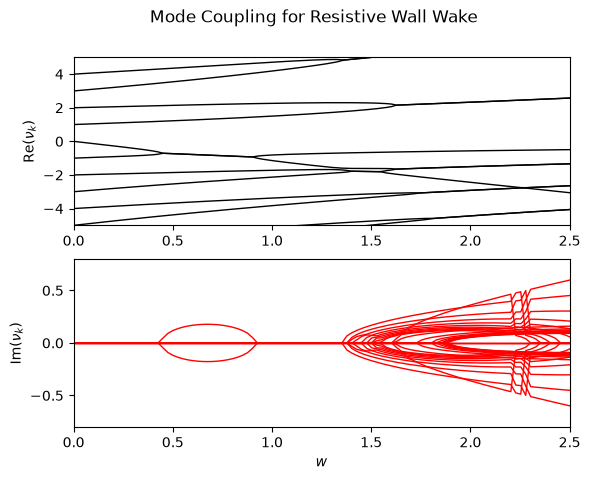

In [31]:
fig, ax = plt.subplots(2)
ax[0].set_ylim(-5,5)
ax[1].set_ylim(-0.8,0.8)
ax[1].set_xlim(0.0,2.5)
ax[0].set_xlim(0.0,2.5)
plt.suptitle("Mode Coupling for Resistive Wall Wake")
ax[1].plot(wscan, im_eigenscan_tracked, color='red', lw=1.0)
ax[0].plot(wscan, re_eigenscan_tracked, color='black', lw=1.0)
ax[1].set_ylabel(r"Im($\nu_{k}$)")
ax[0].set_ylabel(r"Re($\nu_{k}$)")
ax[1].set_xlabel(r"$w$")
plt.savefig("../../plots/pyabs_rw_wake.png", dpi=300)
plt.show()

## Alternatively...

In [32]:
wrange = np.linspace(0.0, 6, num=500)

ans = scan_over_w(basis, wrange=wrange, determine_threshold=True)
im_wscan = np.array(np.imag(ans.eigenvalues))
re_wscan = np.array(np.real(ans.eigenvalues))
ans.eigenvalues.shape

Modes 0 and -1 couple at wth = 0.44488977955911824


(500, 41)

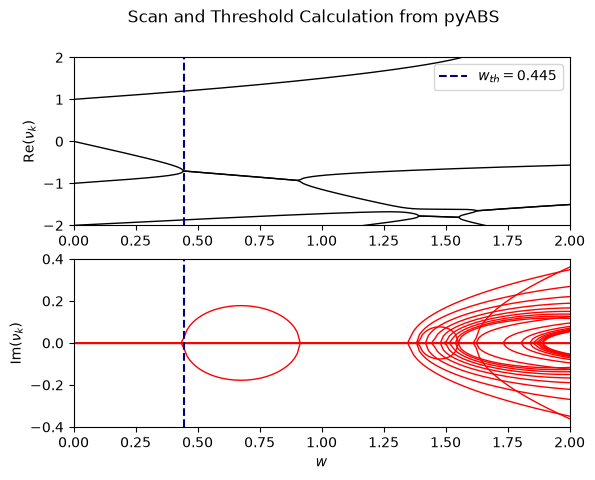

In [34]:
fig, ax = plt.subplots(2)
plt.suptitle("Scan and Threshold Calculation from pyABS")
ax[0].set_ylim(-2,2)
ax[1].set_ylim(-0.4,0.4)
ax[1].set_xlim(0.0,2)
ax[0].set_xlim(0.0,2)
ax[1].plot(ans.wake_parameters, im_wscan, color='red', lw=1.0)
ax[0].plot(ans.wake_parameters, re_wscan, color='black', lw=1.0)
ax[0].vlines(ans.threshold, -2,2, ls = '--', label = rf"$w_{{th}} = {ans.threshold:.03}$", color='navy')
ax[1].vlines(ans.threshold, -0.4,0.4, ls = '--', color='navy')
ax[1].set_ylabel(r"Im($\nu_{k}$)")
ax[0].set_ylabel(r"Re($\nu_{k}$)")
ax[1].set_xlabel(r"$w$")
ax[0].legend()
plt.savefig("../../plots/pyabs_rw.png", dpi=300)
plt.show()

# 2D Parameter Scan and TCMI Threshold for Theta Wake

### Warning : This code can take a while to run

In [ ]:
%%time
from tqdm.notebook import tqdm
resolution = 200
n_max = 500
n_modes = 2*n_max + 1
qmax = 50
wmax = 100
qrange = np.linspace(0.0, qmax, num=resolution)
wrange = np.linspace(0.0, wmax, num=resolution)
imeig_max = np.empty((resolution, resolution), dtype=float)
'''
for i, q in enumerate(qrange):
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
    for j, w in enumerate(wrange):
        theta_wake = ThetaWake(W0=w)
        matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = w))
        imeig_max[j][i] = np.max(np.array(np.abs((-1)*solve_eigenvalues(matrix).imag)))
'''
with tqdm(total=resolution * resolution, desc="Solving eigenvalues") as pbar:
    for i, q in enumerate(qrange):
        basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
        for j, w in enumerate(wrange):
            theta_wake = ThetaWake(W0=w)
            matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w=w))
            imeig_max[j][i] = np.max(np.array(np.abs((-1)*solve_eigenvalues(matrix).imag)))
            pbar.update(1)
        pbar.set_postfix(q=f"{q:.1f}")

rows, cols = np.meshgrid(np.arange(resolution), np.arange(resolution), indexing='ij')
df_matrix = pd.DataFrame({
    'source': 'matrix',
    'row': rows.ravel(),
    'col': cols.ravel(),
    'value': imeig_max.ravel()
})

# Arrays as row/value (col left as NaN)
df_arr1 = pd.DataFrame({'source': 'q', 'row': np.arange(resolution), 'col': np.nan, 'value': qrange})
df_arr2 = pd.DataFrame({'source': 'w', 'row': np.arange(resolution), 'col': np.nan, 'value': wrange})

df_all = pd.concat([df_matrix, df_arr1, df_arr2], ignore_index=True)
df_all.to_csv(f'../../data/{n_modes}modes_{qmax}qmax_{wmax}wmax_{resolution}reso.csv', index=False)

Solving eigenvalues:   0%|          | 0/40000 [00:00<?, ?it/s]

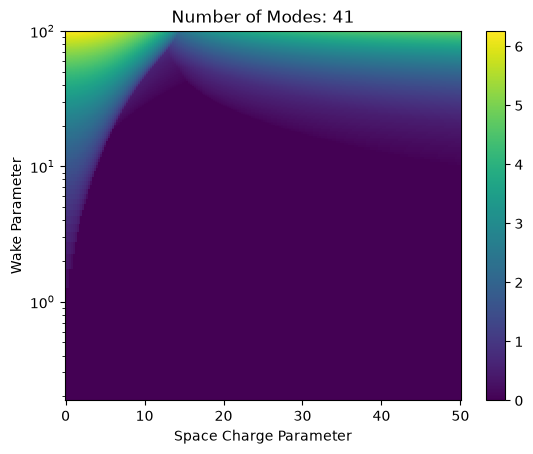

In [11]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(qrange, wrange, imeig_max, norm='linear', cmap='viridis')
ax.set_yscale('log')
ax.set_xlabel('Space Charge Parameter')
ax.set_ylabel('Wake Parameter')
plt.title(f"Number of Modes: {2*n_max+1}")
plt.colorbar(pcm, ax=ax)
plt.show()

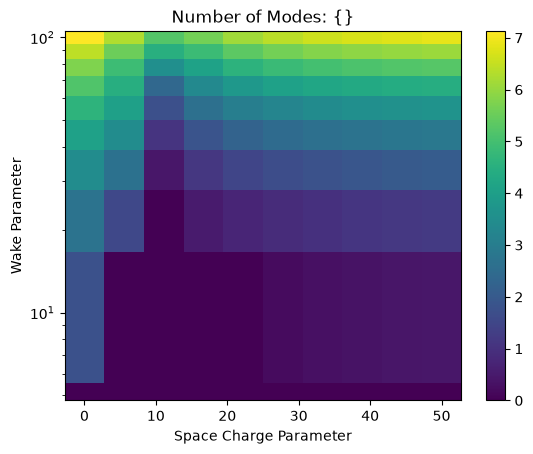

In [49]:
df = pd.read_csv('../../data/10modes_50qmax_100wmax_10reso.csv')

# --- Matrix reconstruction ---
imeigdf = df[df.source == 'matrix']
imeig_data = matrix_df.pivot(index='row', columns='col', values='value').to_numpy()

# --- Array reconstruction ---
qrange_data = df[df.source == 'q'].sort_values('row')['value'].to_numpy()
wrange_data = df[df.source == 'w'].sort_values('row')['value'].to_numpy()


fig, ax = plt.subplots()

pcm = ax.pcolormesh(qrange_data, wrange_data, imeig_data, norm='linear', cmap='viridis')
ax.set_yscale('log')
ax.set_xlabel('Space Charge Parameter')
ax.set_ylabel('Wake Parameter')
plt.title("Number of Modes: {}")
plt.colorbar(pcm, ax=ax)
plt.show()